# HiP-AD Gradient Conflict 분석 노트북

`tools/analyze_gradient_conflict.py` 가 생성한 `gradient_analysis_results/` 디렉토리를 읽어서
교수님 보고에 쓸 수 있는 형태로 정리한다.

## 결과 디렉토리 구조 (script가 만들어 둔 것)
```
gradient_analysis_results/
├── summary_report.md           # 자동 생성된 요약
├── primary.log / supplementary.log
├── ckpt_{1,3,6,18}ep/          # 체크포인트별 한 번씩 돈 결과
│   ├── asymmetry/              # P - P^T heatmap, top_asymmetric_pairs.csv
│   ├── conflict/               # task pair × layer group cosine / conflict_ratio
│   ├── correlation/            # cos ↔ Δloss scatter & 상관계수표
│   ├── gradnorm/               # per-task L2 norm, affinity heatmap
│   └── probe/                  # task→task Δloss probe matrix
├── dynamics/                   # 체크포인트 가로지른 시계열
│   ├── cos_dynamics.csv
│   ├── helpful_dynamics.csv
│   ├── norm_dynamics.csv
│   └── timeseries_*.png
└── supplementary/              # probe 보충 (steps × variant)
```

## 어떤 데이터를 보고 있는지
- **task**: `det` / `map` / `motion` / `plan` (ego는 일부 결과에서 NaN — script가 ego loss key 매칭을 못 함, 보고서 caveat 으로 적어둠)
- **group**: backbone(stem, layer1~4) + decoder layer 0~5의 sub-module들 (ffn_fc1, ffn_fc2, pre_norm, gnn, inter_gnn, norm_0/1, identity_fc)
- **probe**: 한 task 의 gradient 만으로 1 step 옵티마이저 step → 다른 task loss 가 얼마나 변하는지(Δloss). raw / normalized × 1step / 2step 4가지.
- **conflict_ratio**: per-batch 에서 cos(grad_a, grad_b) < 0 인 비율
- **helpful_ratio (a→b)**: a 방향 step 후 b loss가 *감소*한 batch 비율
- **asymmetry**: probe matrix `P[a,b]` 에 대해 antisymmetric part `(P - P^T)/2` 의 크기

In [1]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown

BASE = Path('/home/yongjae/e2e/HiP-AD/gradient_analysis_results')
CKPTS = [1, 3, 6, 18]
TASKS = ['det', 'map', 'motion', 'plan']
PAIRS = [('det','map'),('det','motion'),('det','plan'),
         ('map','motion'),('map','plan'),('motion','plan')]

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.4f}'.format)
print('데이터 디렉토리:', BASE)
print('체크포인트:', CKPTS)

데이터 디렉토리: /home/yongjae/e2e/HiP-AD/gradient_analysis_results
체크포인트: [1, 3, 6, 18]


---
## A. Gradient norm dynamics

각 task가 backbone+decoder 공유 파라미터에 만드는 gradient 의 L2 norm 이 학습이 진행됨에 따라
어떻게 변하는지 본다. **한 task가 압도적으로 큰 gradient를 가진다면 unweighted multi-task 학습은
사실상 그 task에 끌려간다.**

task,det,map,motion,plan
epoch,,,,
1.0000,1.2790,0.7000,0.1880,0.9340
3.0000,1.3360,0.6220,0.2730,1.1130
6.0000,1.2450,0.6420,0.3010,0.9700
18.0000,1.6190,0.6510,0.4110,0.8940


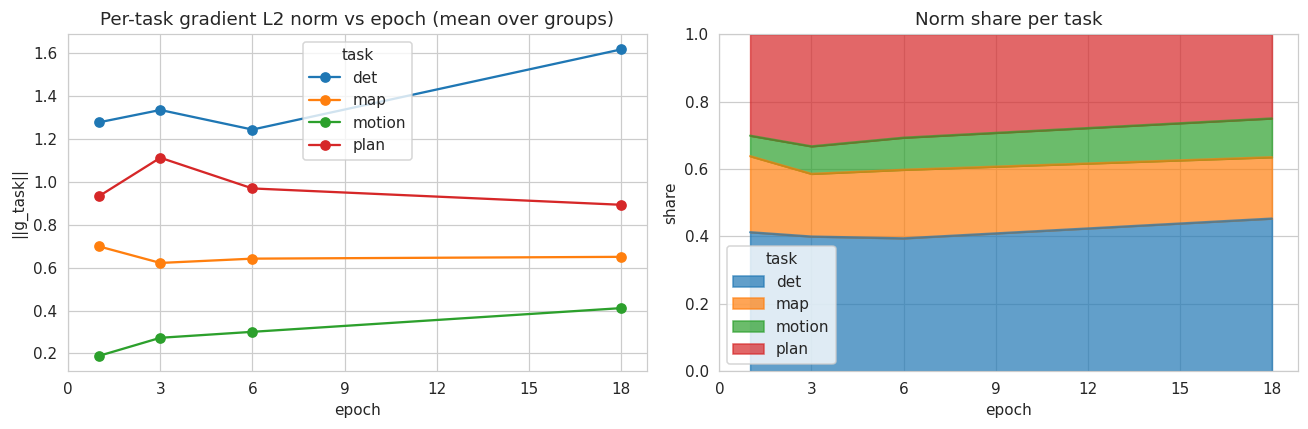

In [19]:
norm_dyn = pd.read_csv(BASE/'dynamics/norm_dynamics.csv')
norm_pivot = norm_dyn.pivot(index='epoch', columns='task', values='mean_norm')[TASKS]
display(norm_pivot.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
norm_pivot.plot(ax=axes[0], marker='o')
axes[0].set_title('Per-task gradient L2 norm vs epoch (mean over groups)')
axes[0].set_ylabel('||g_task||')
(norm_pivot.div(norm_pivot.sum(axis=1), axis=0)).plot.area(
    ax=axes[1], stacked=True, alpha=0.7)
axes[1].set_title('Norm share per task')
axes[1].set_ylabel('share')
axes[1].set_ylim(0, 1)
for ax in axes:
    ax.set_xticks(range(0, 19, 3))
plt.tight_layout(); plt.show()

task,det,map,motion,plan,det/motion,det/map
group,,,,,,
dec0_ffn_0_fc1,2.9600,1.2000,0.5900,1.3500,5.0600,2.4600
dec0_gnn_0,0.2600,1.8500,0.0500,1.6800,4.8200,0.1400
dec0_ffn_0_pre_norm,0.5100,0.2100,0.1100,0.3200,4.8100,2.4600
dec0_norm_0,0.3200,0.1600,0.0700,0.2200,4.7500,1.9500
backbone_stem,6.0800,2.0800,1.2900,2.8300,4.7100,2.9300
backbone_layer1,7.8400,2.5600,1.6900,3.6000,4.6400,3.0600
backbone_layer2,9.7700,3.0100,2.1100,4.2100,4.6300,3.2500
dec0_ffn_0_identity_fc,4.1600,1.8000,0.9100,2.0200,4.5500,2.3100
dec0_ffn_0_fc2,1.3200,0.8300,0.2900,0.9000,4.4800,1.5900


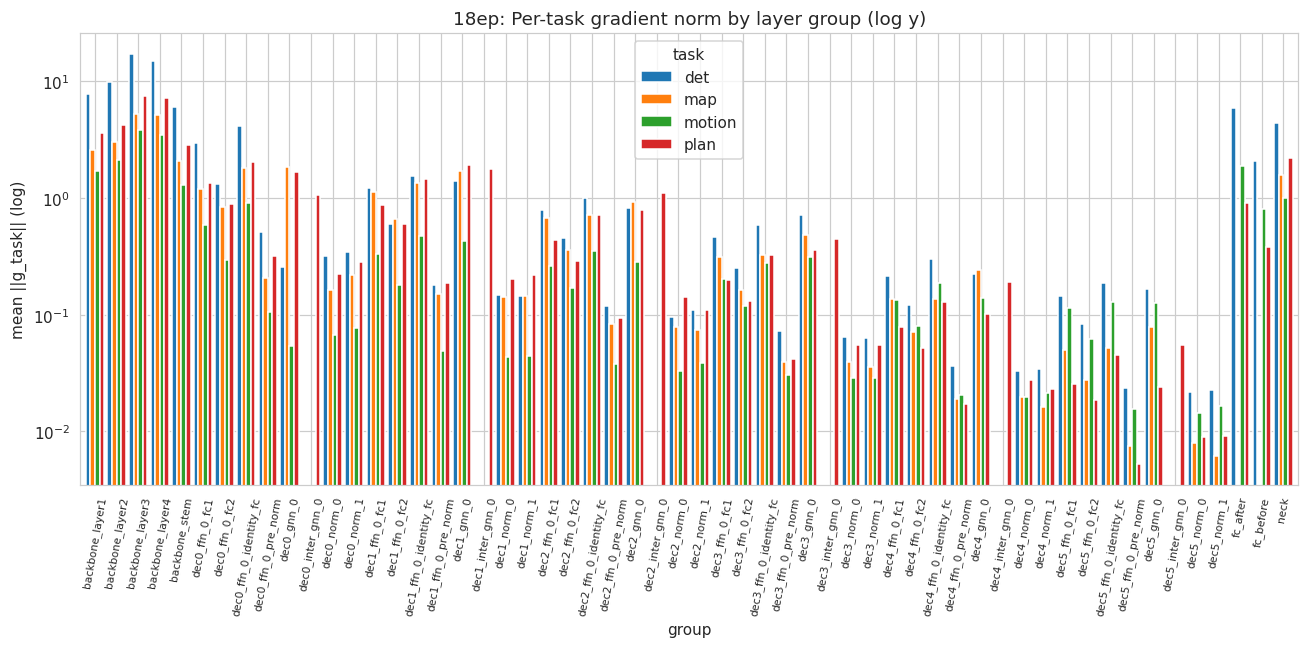

In [3]:
# 18ep에서 layer group 단위로 어디서 det dominance가 가장 심한지
norm_lg = pd.read_csv(BASE/'ckpt_18ep/gradnorm/per_task_norm.csv')
norm_lg_mean = norm_lg.groupby(['task','group'])['norm'].mean().unstack('task')[TASKS]
norm_lg_mean['det/motion'] = norm_lg_mean['det'] / norm_lg_mean['motion']
norm_lg_mean['det/map']    = norm_lg_mean['det'] / norm_lg_mean['map']
display(norm_lg_mean.sort_values('det/motion', ascending=False).head(10).round(2))

fig, ax = plt.subplots(figsize=(12, 6))
norm_lg_mean[TASKS].plot.bar(stacked=False, ax=ax, width=0.85)
ax.set_yscale('log')
ax.set_title('18ep: Per-task gradient norm by layer group (log y)')
ax.set_ylabel('mean ||g_task|| (log)')
ax.tick_params(axis='x', labelrotation=80, labelsize=7)
plt.tight_layout(); plt.show()

---
## B. Probe matrix: task → task Δloss

`P[i,j]` = task i 의 gradient만으로 1-step 옵티마이저 step 을 적용했을 때 task j loss 가 얼마나 변하는지.
- 대각선 P[i,i] : i task 자기 자신은 loss 가 (이 batch 안에서) 얼마나 감소/증가했는지 → raw 인 경우 step size에 비례
- 비대각선 양수 : i 의 step 이 j loss 를 *증가*시킴 → **i ↔ j 가 충돌**
- 비대각선 음수 : i 의 step 이 j loss 도 *감소*시킴 → **양립**

결과는 `ckpt_{ep}ep/probe/probe_matrix_1step_raw.csv` 에 들어 있다.

/tmp/ipykernel_4149995/2344017942.py:14: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4149995/2344017942.py:14: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4149995/2344017942.py:14: UserWarning: Glyph 52649 (\N{HANGUL SYLLABLE CUNG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4149995/2344017942.py:14: UserWarning: Glyph 46028 (\N{HANGUL SYLLABLE DOL}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4149995/2344017942.py:14: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4149995/2344017942.py:14: UserWarning: Glyph 47549 (\N{HANGUL SYLLABLE RIB}) missing from current font.
  plt.tight_layout(); plt.show()
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtools

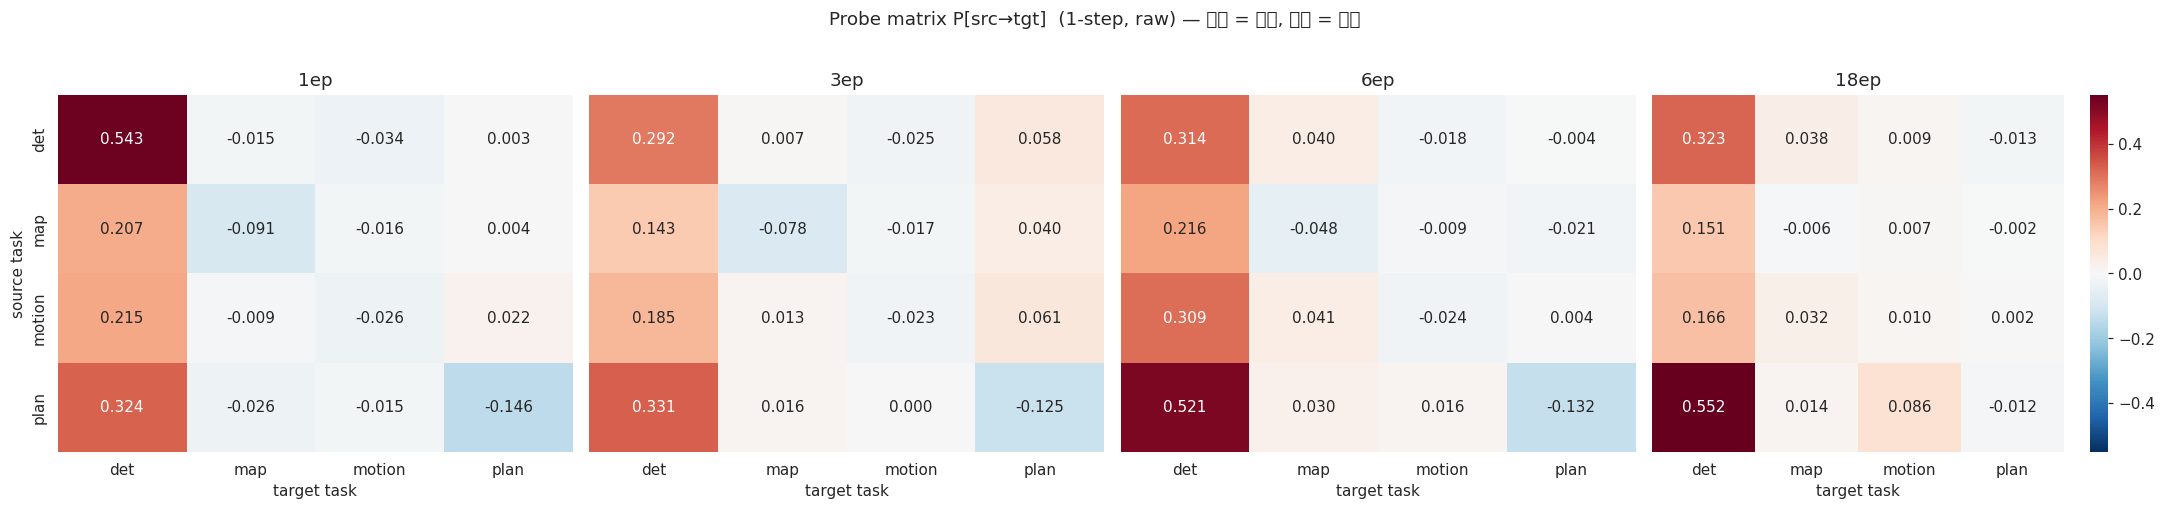

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
vmax = 0
probes = {}
for ep in CKPTS:
    df = pd.read_csv(BASE/f'ckpt_{ep}ep/probe/probe_matrix_1step_raw.csv').set_index('source_task')
    probes[ep] = df
    vmax = max(vmax, df.abs().values.max())
for ax, ep in zip(axes, CKPTS):
    sns.heatmap(probes[ep], annot=True, fmt='.3f', cmap='RdBu_r',
                center=0, vmin=-vmax, vmax=vmax, ax=ax, cbar=(ep==CKPTS[-1]))
    ax.set_title(f'{ep}ep')
    ax.set_xlabel('target task'); ax.set_ylabel('source task' if ep==CKPTS[0] else '')
fig.suptitle('Probe matrix P[src→tgt]  (1-step, raw) — 양수 = 충돌, 음수 = 양립', y=1.02)
plt.tight_layout(); plt.show()

In [5]:
# 비대각선만 끌어내서 정렬
rows = []
for ep, df in probes.items():
    for s in TASKS:
        for t in TASKS:
            if s == t: continue
            rows.append(dict(epoch=ep, src=s, tgt=t, dloss=df.loc[s, t]))
off = pd.DataFrame(rows)
print('=== 18ep 가장 큰 (양수=충돌) off-diagonal Top-5 ===')
display(off.query('epoch==18').nlargest(5, 'dloss'))
print('=== 18ep 가장 작은 (음수=양립) off-diagonal Top-5 ===')
display(off.query('epoch==18').nsmallest(5, 'dloss'))

=== 18ep 가장 큰 (양수=충돌) off-diagonal Top-5 ===


,epoch,src,tgt,dloss
45,18,plan,det,0.5522
42,18,motion,det,0.1659
39,18,map,det,0.1506
47,18,plan,motion,0.0858
36,18,det,map,0.0378


=== 18ep 가장 작은 (음수=양립) off-diagonal Top-5 ===


,epoch,src,tgt,dloss
38,18,det,plan,-0.0133
41,18,map,plan,-0.0020
44,18,motion,plan,0.0020
40,18,map,motion,0.0066
37,18,det,motion,0.0090


---
## C. Asymmetric interaction

Probe matrix 는 **방향성**이 있다 (`P[plan,det] ≠ P[det,plan]`). 이 비대칭의 크기 `(P - P^T)/2` 가
task간 충돌이 reciprocal 이 아닌 정도를 보여 준다. summary_report.md 의 _top asymmetric pairs_ 표에
해당.

epoch,1,3,6,18
pair,,,,
det|map,0.1110,0.0680,0.0880,0.0560
det|motion,0.1240,0.1050,0.1630,0.0780
det|plan,0.1600,0.1370,0.2620,0.2830
map|motion,0.0030,0.0150,0.0250,0.0130
map|plan,0.0150,0.0120,0.0250,0.0080
motion|plan,0.0180,0.0300,0.0060,0.0420


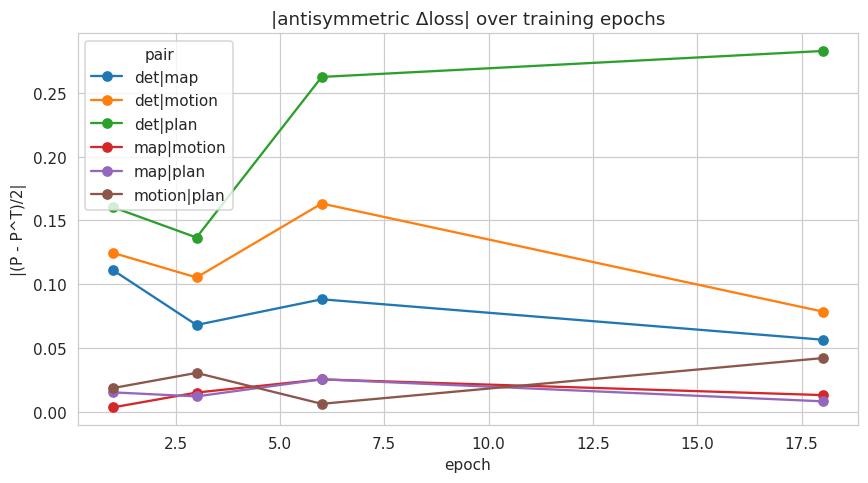

In [6]:
asym_dyn = []
for ep, P in probes.items():
    A = (P.values - P.values.T) / 2
    for i, a in enumerate(P.index):
        for j, b in enumerate(P.columns):
            if j <= i: continue
            asym_dyn.append(dict(epoch=ep, pair=f'{a}|{b}', antisym=A[i, j], abs_antisym=abs(A[i, j])))
asym_df = pd.DataFrame(asym_dyn)
asym_pivot = asym_df.pivot(index='pair', columns='epoch', values='abs_antisym')
display(asym_pivot.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
asym_pivot.T.plot(ax=ax, marker='o')
ax.set_title('|antisymmetric Δloss| over training epochs')
ax.set_xlabel('epoch'); ax.set_ylabel('|(P - P^T)/2|')
ax.legend(title='pair', loc='upper left'); plt.tight_layout(); plt.show()

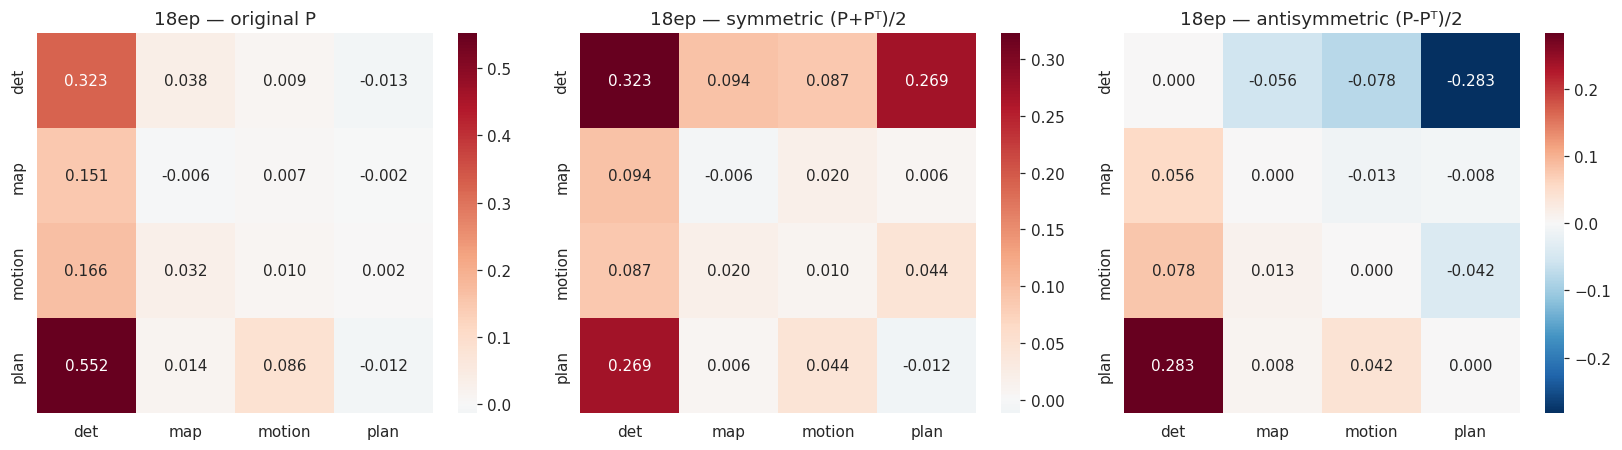

In [7]:
# 18ep 비대칭 행렬 자체를 시각화
P18 = probes[18]
A18 = (P18.values - P18.values.T) / 2
S18 = (P18.values + P18.values.T) / 2
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, M, title in zip(axes, [P18.values, S18, A18], ['original P', 'symmetric (P+Pᵀ)/2', 'antisymmetric (P-Pᵀ)/2']):
    sns.heatmap(M, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                xticklabels=P18.columns, yticklabels=P18.index, ax=ax)
    ax.set_title(f'18ep — {title}')
plt.tight_layout(); plt.show()

---
## D. Gradient cosine ↔ Δloss 상관관계

흔히 쓰이는 "cos < 0 → task가 충돌" 휴리스틱이 이 모델에서 실제 Δloss 와 얼마나 잘 맞는지 본다.
각 batch 단위로 (cos, Δloss) 쌍을 모아 Pearson / Spearman 으로 측정. 4개 체크포인트 × 6개 pair × 2 step ×
raw/normalized 합쳐서 한 표에 정리한다.

In [8]:
corr_all = []
for ep in CKPTS:
    c = pd.read_csv(BASE/f'ckpt_{ep}ep/correlation/correlation_table.csv')
    c['epoch'] = ep
    corr_all.append(c)
corr_all = pd.concat(corr_all, ignore_index=True)

# 1-step raw 기준
sub = corr_all.query('steps==1 and variant=="raw"')
pear = sub.pivot_table(index=['task_a','task_b'], columns='epoch', values='pearson')
print('Pearson(cos, Δloss)  — 1step raw'); display(pear.round(3))
spear = sub.pivot_table(index=['task_a','task_b'], columns='epoch', values='spearman')
print('Spearman(cos, Δloss) — 1step raw'); display(spear.round(3))

Pearson(cos, Δloss)  — 1step raw


epoch              1       3       6       18
task_a task_b                                
det    map     0.1040 -0.1880  0.1100  0.1010
       motion -0.2680 -0.0280 -0.1250  0.0890
       plan    0.1110 -0.0050 -0.0040  0.0560
map    motion  0.0140  0.0090  0.0690  0.0520
       plan   -0.0070 -0.1100 -0.1480 -0.0590
motion plan   -0.1360 -0.0270  0.1270  0.0030

Spearman(cos, Δloss) — 1step raw


epoch              1       3       6       18
task_a task_b                                
det    map     0.1550 -0.1550  0.1520  0.1130
       motion -0.3670 -0.0230 -0.0200  0.2140
       plan    0.0800  0.0140 -0.0540  0.0060
map    motion -0.0070  0.1010  0.0350  0.0760
       plan   -0.0290 -0.1140 -0.1190 -0.1110
motion plan   -0.1460 -0.0270  0.1570  0.0240

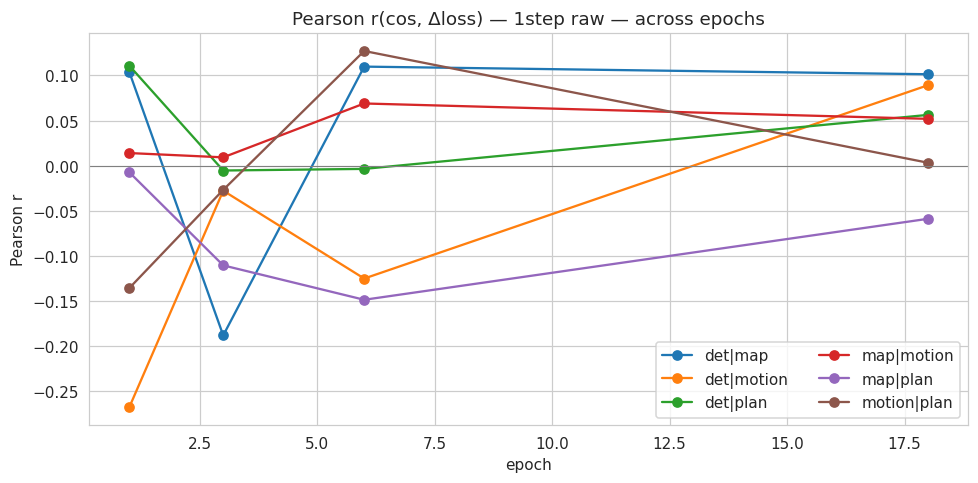

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for (a, b), row in pear.iterrows():
    ax.plot(row.index, row.values, marker='o', label=f'{a}|{b}')
ax.axhline(0, color='gray', lw=0.7)
ax.set_title('Pearson r(cos, Δloss) — 1step raw — across epochs')
ax.set_xlabel('epoch'); ax.set_ylabel('Pearson r')
ax.legend(loc='best', ncol=2); plt.tight_layout(); plt.show()

**해석 포인트** : |r| 이 대부분 0.3 미만이고 sign 도 epoch별로 뒤집힌다 → 단순 cosine 으로
충돌을 *예측*하기는 어렵다. 즉 PCGrad 류 surgery 가 batch 단위로 의미있는 신호를 줄지
회의적임. (보고서에서 "방향성보다 magnitude 관점이 더 의미가 있다" 는 근거로 쓸 수 있다.)

---
## E. Layer-wise conflict pattern

`ckpt_{ep}ep/conflict/conflict_{a}_{b}_summary.csv` 가 layer-group × pair 단위로 mean cosine, 
conflict_ratio (cos<0 비율) 을 들고 있다. 어느 layer 에서 충돌이 가장 많이 일어나는지 본다.

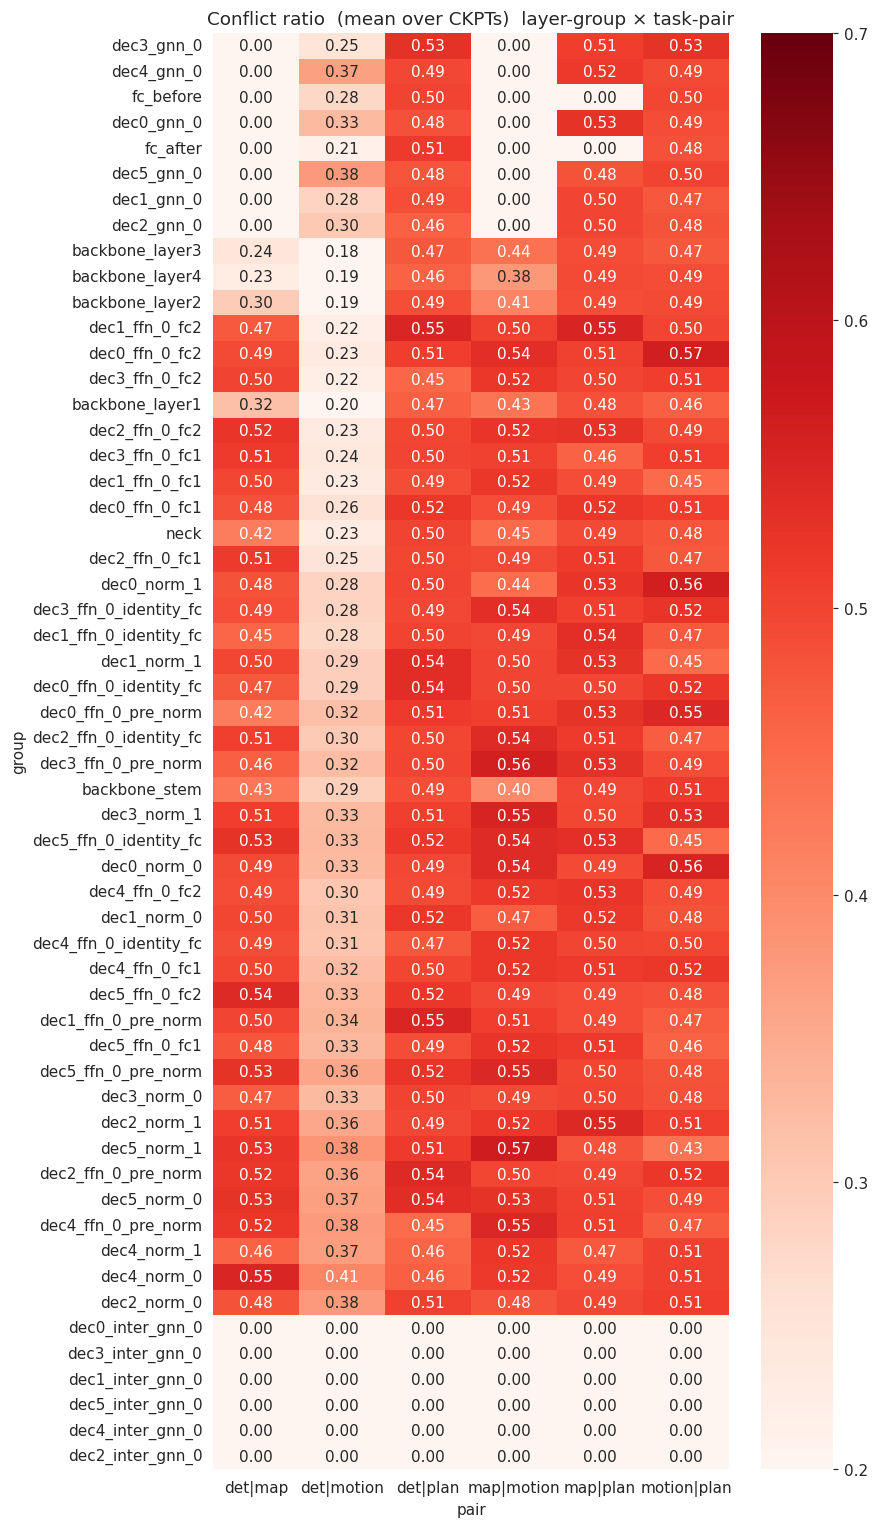

In [10]:
def load_pair_summary(ep, a, b):
    df = pd.read_csv(BASE/f'ckpt_{ep}ep/conflict/conflict_{a}_{b}_summary.csv')
    df['pair'] = f'{a}|{b}'; df['epoch'] = ep
    return df

all_summary = pd.concat(
    [load_pair_summary(ep, a, b) for ep in CKPTS for a, b in PAIRS],
    ignore_index=True)

# pair × layer-group 평균 conflict_ratio (전 epoch 평균)
heat = (all_summary.groupby(['pair','group'])['conflict_ratio']
        .mean().unstack('pair').dropna(how='all'))
heat = heat.loc[heat.std(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(8, 14))
sns.heatmap(heat, cmap='Reds', vmin=0.2, vmax=0.7, annot=True, fmt='.2f', ax=ax)
ax.set_title('Conflict ratio  (mean over CKPTs)  layer-group × task-pair')
plt.tight_layout(); plt.show()

/tmp/ipykernel_4149995/3728617117.py:8: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from current font.
  ax.legend(loc='best', ncol=3); plt.tight_layout(); plt.show()
/tmp/ipykernel_4149995/3728617117.py:8: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from current font.
  ax.legend(loc='best', ncol=3); plt.tight_layout(); plt.show()
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


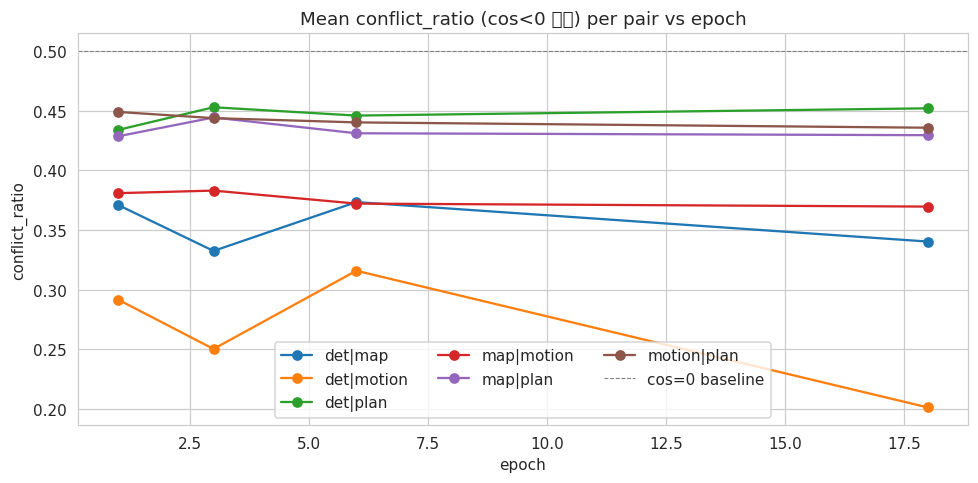

In [11]:
# pair 별 epoch 추이 (layer-group 평균)
trend = all_summary.groupby(['epoch','pair'])['conflict_ratio'].mean().unstack('pair')
fig, ax = plt.subplots(figsize=(9, 4.5))
trend.plot(ax=ax, marker='o')
ax.axhline(0.5, color='gray', lw=0.7, linestyle='--', label='cos=0 baseline')
ax.set_title('Mean conflict_ratio (cos<0 비율) per pair vs epoch')
ax.set_xlabel('epoch'); ax.set_ylabel('conflict_ratio')
ax.legend(loc='best', ncol=3); plt.tight_layout(); plt.show()

In [12]:
# 18ep 에서 pair별 가장 충돌이 잦은 top-3 group
for a, b in PAIRS:
    df = load_pair_summary(18, a, b)
    print(f'\n[{a}|{b}] @18ep top-3 most-conflict layer groups')
    print(df.nlargest(3, 'conflict_ratio')[['group','mean_cos','conflict_ratio']]
          .to_string(index=False))


[det|map] @18ep top-3 most-conflict layer groups
          group  mean_cos  conflict_ratio
 dec1_ffn_0_fc1   -0.0003          0.5400
 dec5_ffn_0_fc1   -0.0001          0.5300
 dec5_ffn_0_fc2   -0.0002          0.5300

[det|motion] @18ep top-3 most-conflict layer groups
               group  mean_cos  conflict_ratio
 dec4_ffn_0_pre_norm    0.0354          0.3900
         dec4_norm_0    0.0346          0.3800
         dec5_norm_1    0.0399          0.3600

[det|plan] @18ep top-3 most-conflict layer groups
                  group  mean_cos  conflict_ratio
            dec1_norm_0   -0.0126          0.6500
 dec0_ffn_0_identity_fc   -0.0006          0.6100
    dec3_ffn_0_pre_norm   -0.0128          0.5800

[map|motion] @18ep top-3 most-conflict layer groups
               group  mean_cos  conflict_ratio
      dec2_ffn_0_fc1   -0.0004          0.6000
 dec4_ffn_0_pre_norm   -0.0102          0.5900
         dec4_norm_0   -0.0106          0.5900

[map|plan] @18ep top-3 most-conflict layer group

---
## F. Helpful-ratio dynamics

한 task 의 step 이 다른 task loss 를 *낮춘* batch 비율. helpful_ratio < 0.5 이면 그 방향 step 이
오히려 해롭다는 의미. 학습이 진행되며 task 간 helpful → harmful 로 바뀌는지 본다.

pair,det→map,det→motion,det→plan,map→det,map→motion,map→plan,motion→det,motion→map,motion→plan,plan→det,plan→map,plan→motion
epoch,,,,,,,,,,,,
1.0000,0.5200,0.6000,0.4800,0.4100,0.5200,0.4700,0.3200,0.5200,0.4500,0.2500,0.5600,0.5000
3.0000,0.5100,0.5000,0.4300,0.4300,0.5300,0.4400,0.3800,0.4500,0.4400,0.3300,0.4300,0.4200
6.0000,0.4500,0.5900,0.5800,0.3200,0.5100,0.5300,0.2900,0.3400,0.5100,0.2400,0.4300,0.4100
18.0000,0.3500,0.3500,0.5600,0.4000,0.3200,0.5300,0.3200,0.3600,0.5000,0.2200,0.5300,0.1100


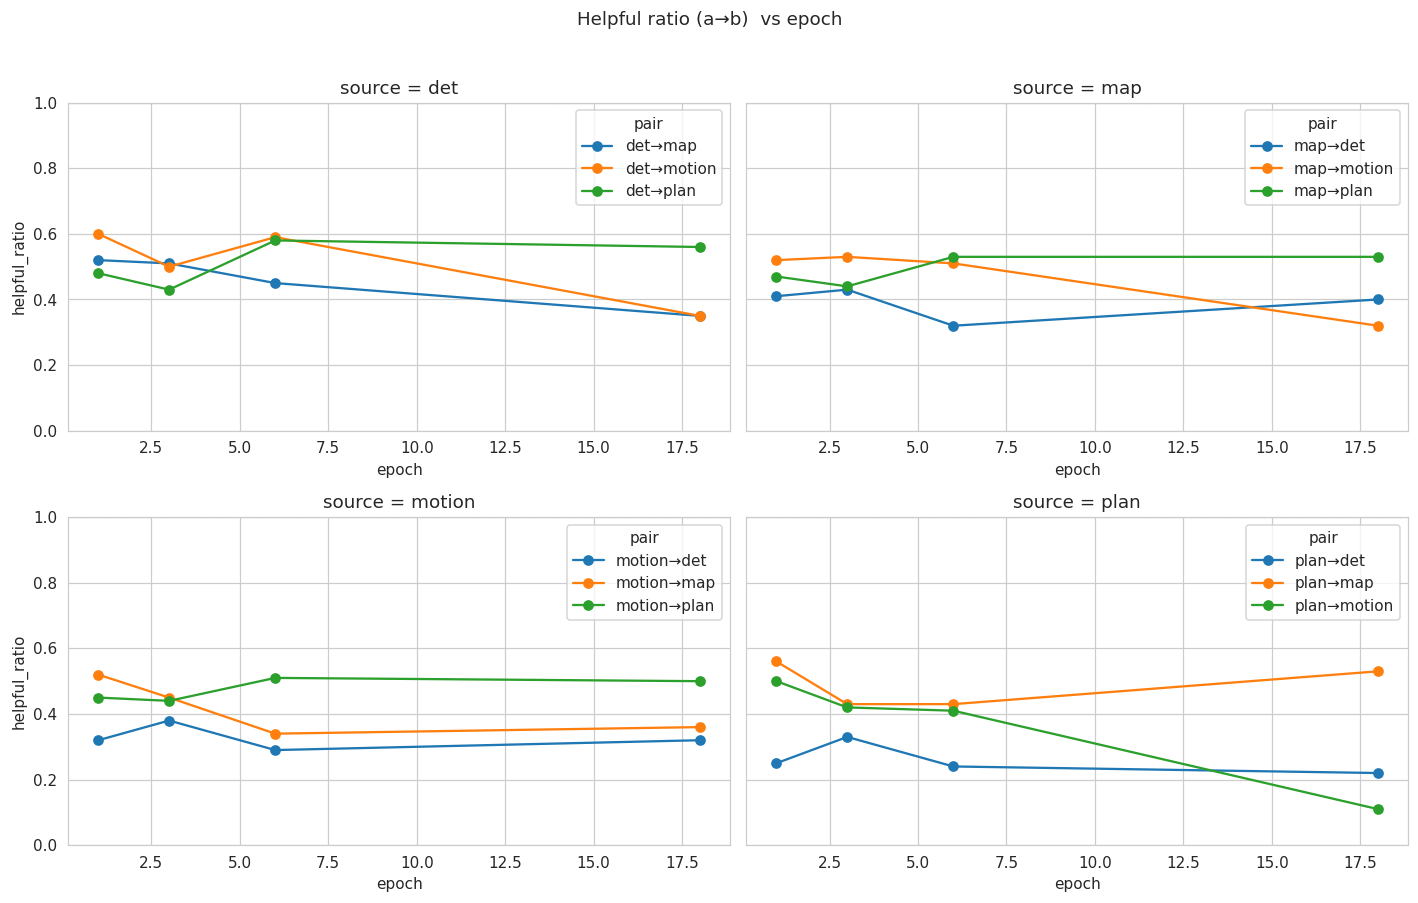

In [ ]:
help_dyn = pd.read_csv(BASE/'dynamics/helpful_dynamics.csv')
help_pivot = help_dyn.pivot(index='epoch', columns='pair', values='helpful_ratio')
display(help_pivot.round(2))

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for ax, src in zip(axes.flat, TASKS):
    cols = [c for c in help_pivot.columns if c.startswith(f'{src}→')]
    help_pivot[cols].plot(ax=ax, marker='o')
    ax.axhline(0.5, color='gray', lw=0.7, linestyle='--')
    ax.set_title(f'source = {src}')
    ax.set_ylim(0, 1); ax.set_ylabel('helpful_ratio')
fig.suptitle('Helpful ratio (a→b)  vs epoch', y=1.02)
plt.tight_layout(); plt.show()

/tmp/ipykernel_4149995/2123530244.py:8: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4149995/2123530244.py:8: UserWarning: Glyph 50880 (\N{HANGUL SYLLABLE UM}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4149995/2123530244.py:8: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4149995/2123530244.py:8: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from current font.
  plt.tight_layout(); plt.show()
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50880 (\N{HANGUL SYLLABLE UM}) missing from current font.
  fig.canva

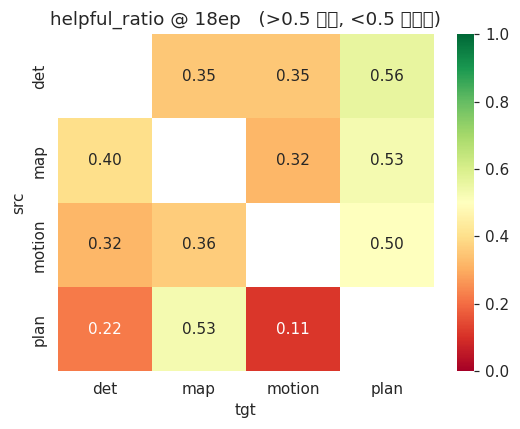

In [14]:
# 18ep helpful_ratio 행렬화
h18 = help_dyn.query('epoch==18').copy()
h18[['src','tgt']] = h18['pair'].str.split('→', expand=True)
mat = h18.pivot(index='src', columns='tgt', values='helpful_ratio').reindex(index=TASKS, columns=TASKS)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(mat, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5, vmin=0, vmax=1, ax=ax)
ax.set_title('helpful_ratio @ 18ep   (>0.5 도움, <0.5 해로움)')
plt.tight_layout(); plt.show()

---
## G. 미리 그려진 시각화 (script 가 생성한 PNG)

디버깅이나 보고서 figure 로 그대로 재활용 가능.

### dynamics/timeseries_norm.png

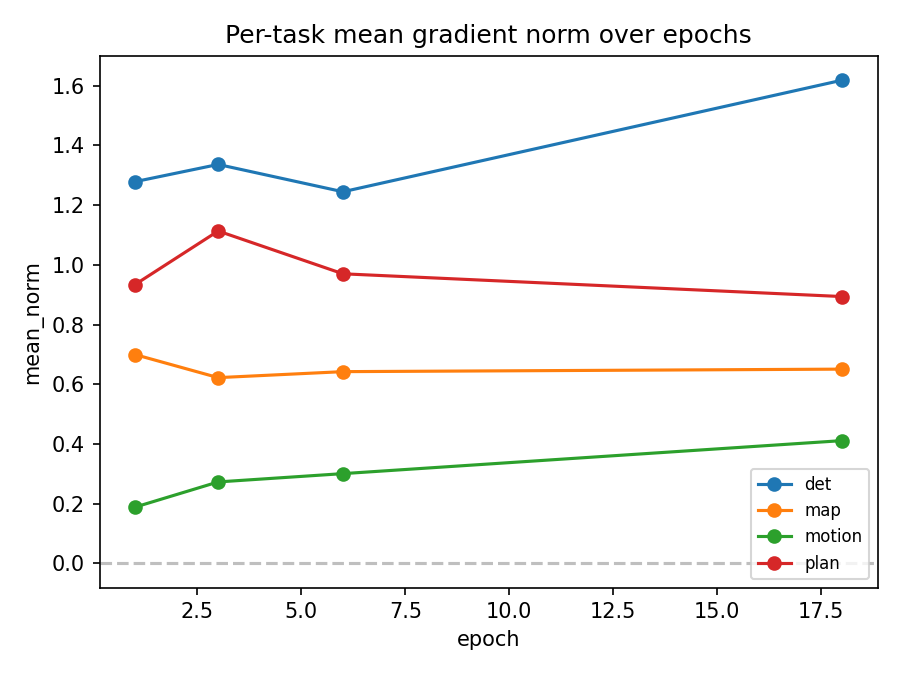

### dynamics/timeseries_cosine.png

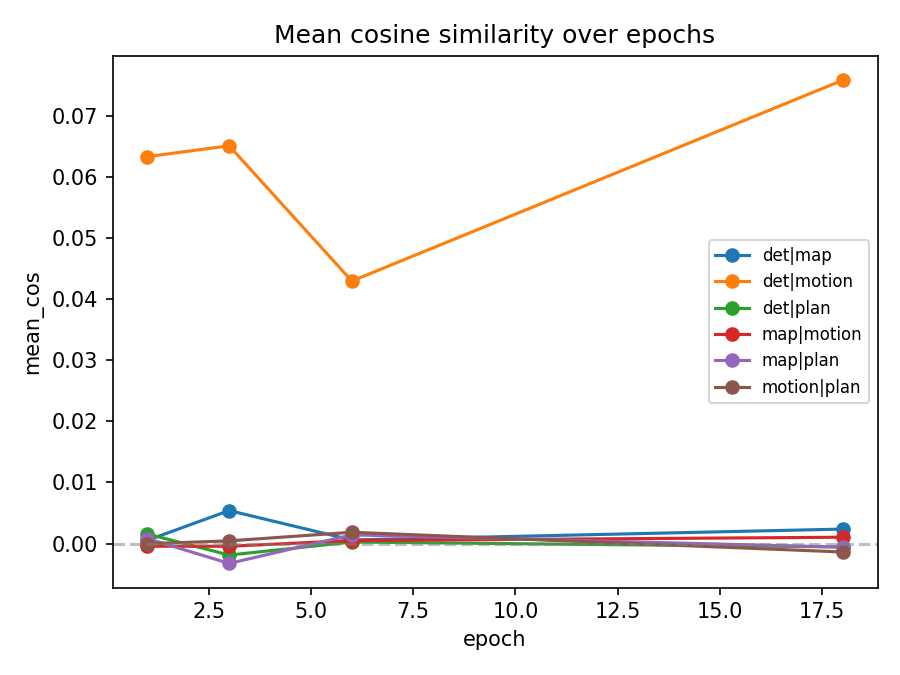

### dynamics/timeseries_conflict_ratio.png

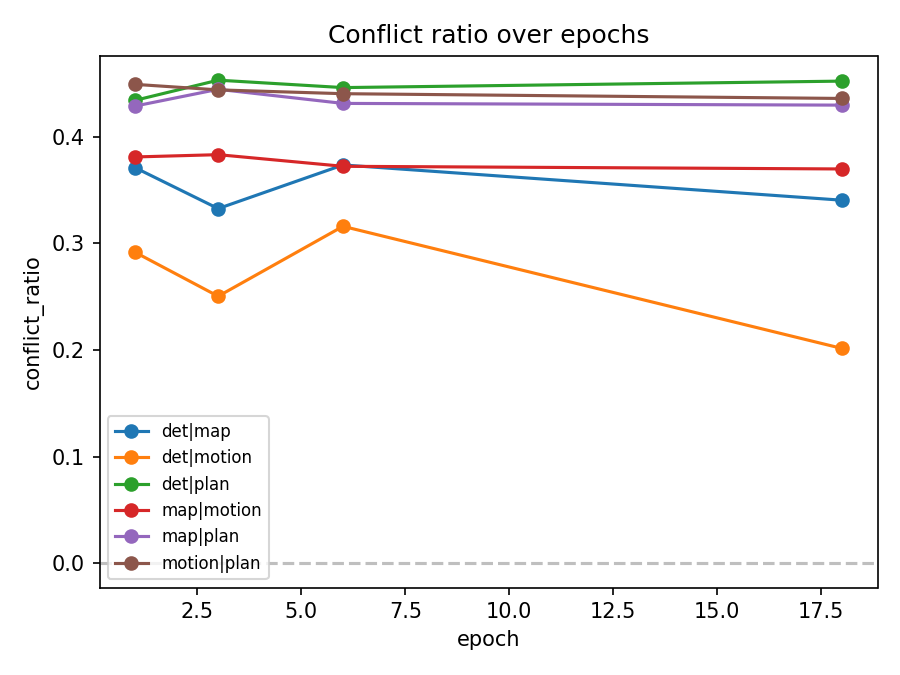

### dynamics/timeseries_helpful.png

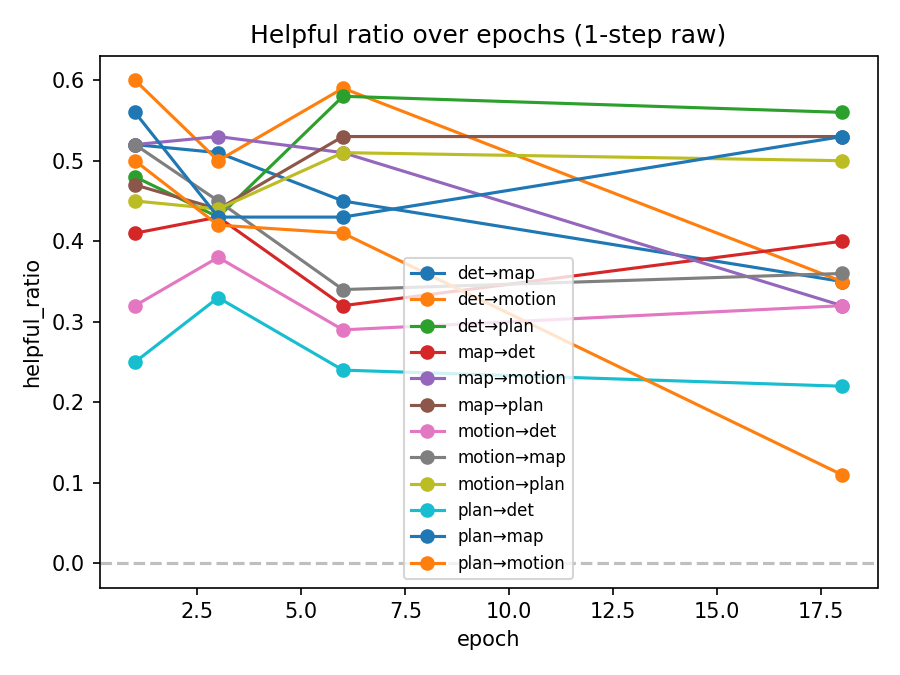

In [15]:
for name in ['timeseries_norm.png','timeseries_cosine.png',
             'timeseries_conflict_ratio.png','timeseries_helpful.png']:
    p = BASE/'dynamics'/name
    if p.exists():
        display(Markdown(f'### dynamics/{name}'))
        display(Image(filename=str(p)))

### 1ep — asymmetry/antisymmetric.png

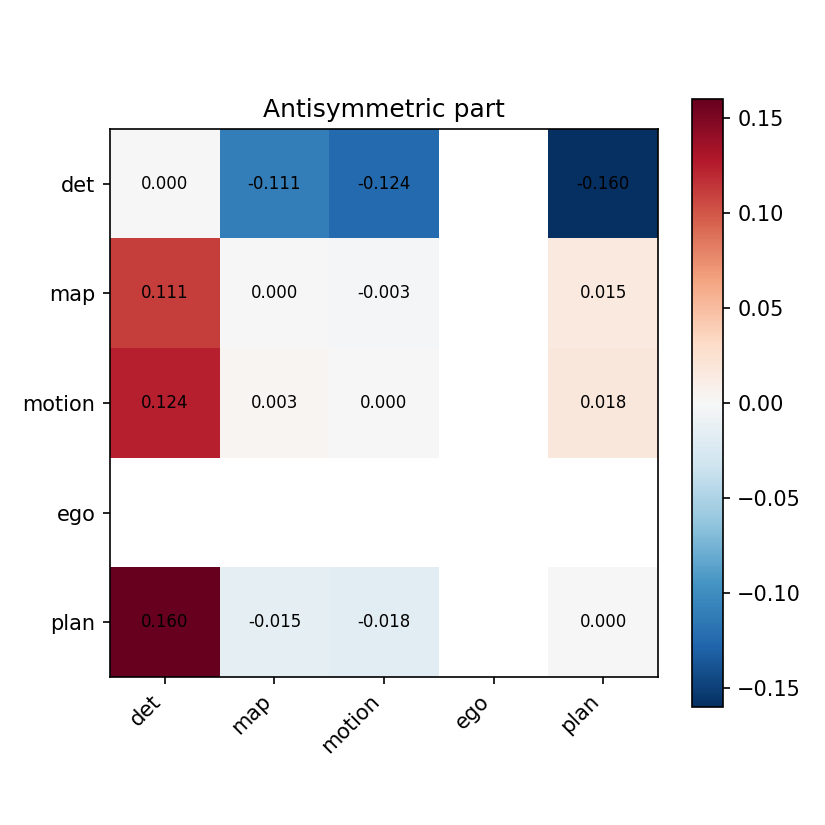

### 1ep — asymmetry/original.png

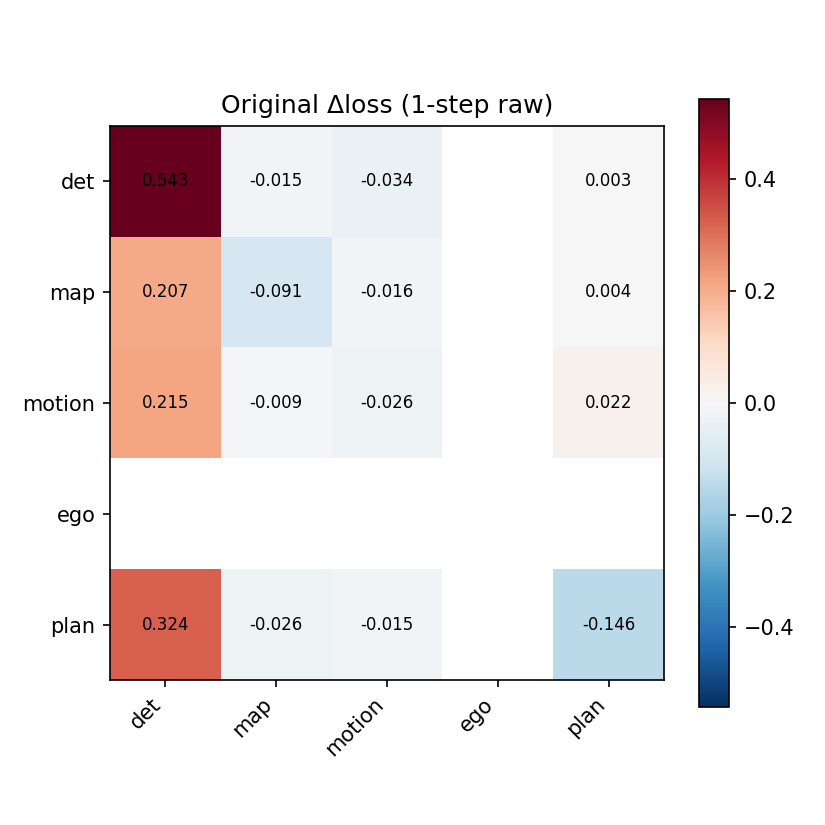

### 1ep — gradnorm/affinity_matrix_1step_raw.png

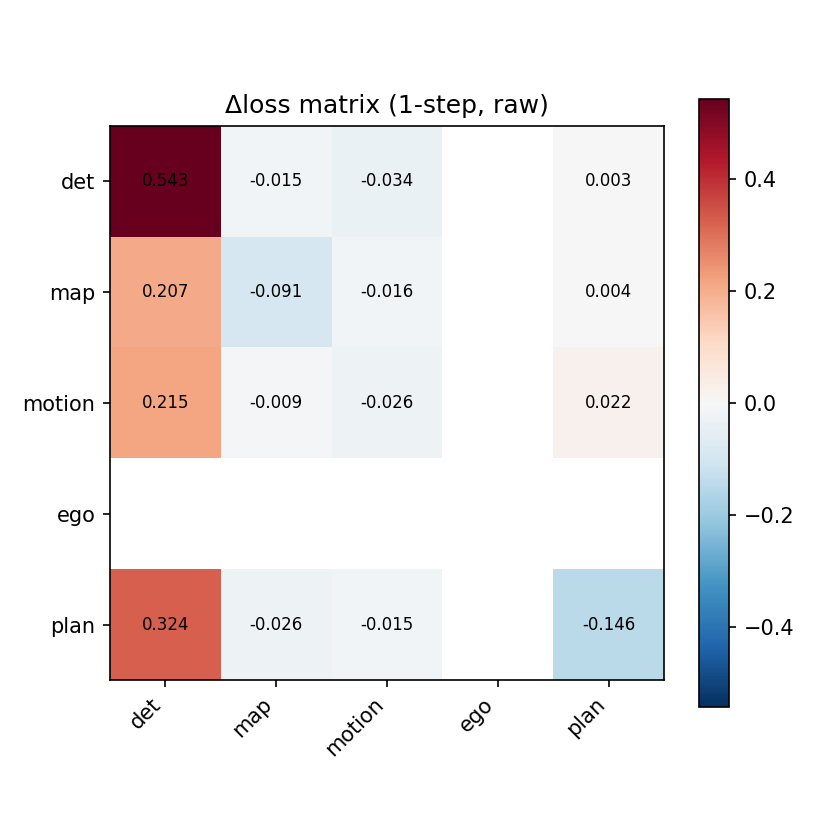

### 1ep — gradnorm/norm_ratio_heatmap.png

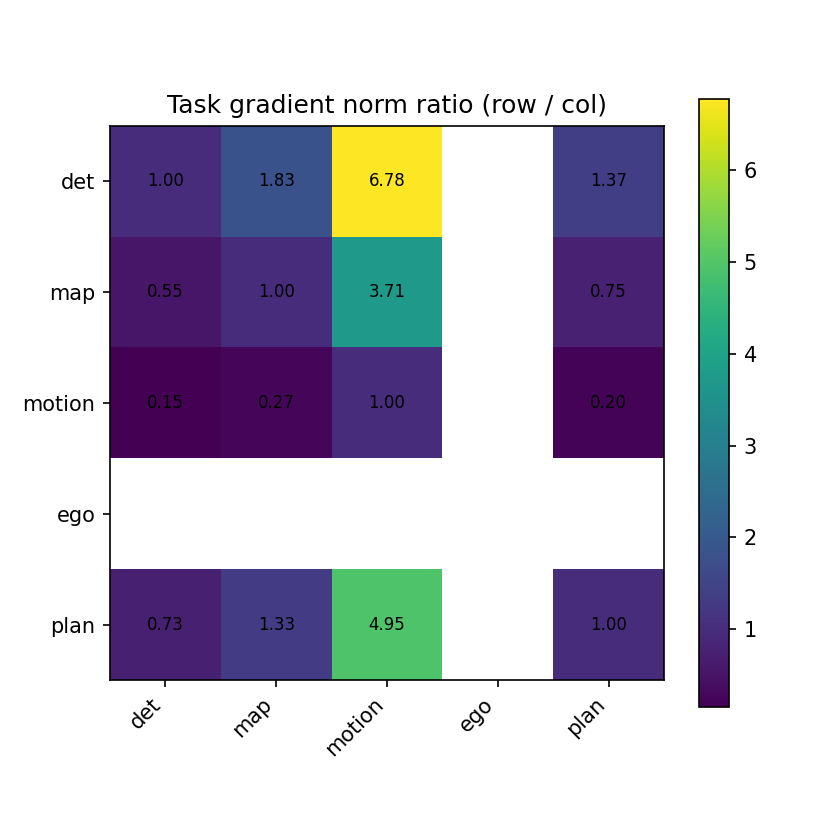

### 1ep — conflict/cosine_violin.png

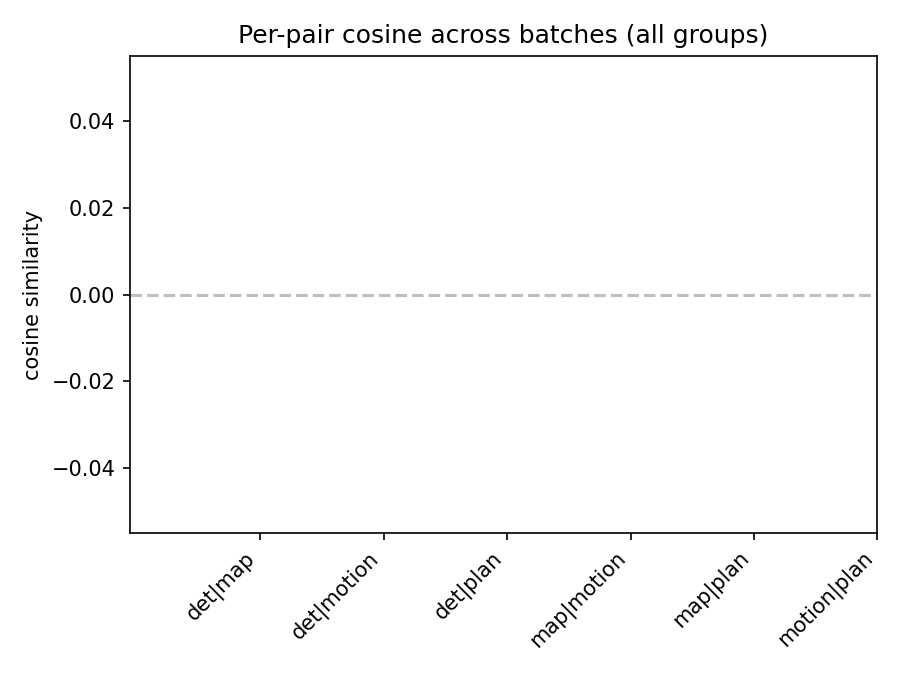

### 3ep — asymmetry/antisymmetric.png

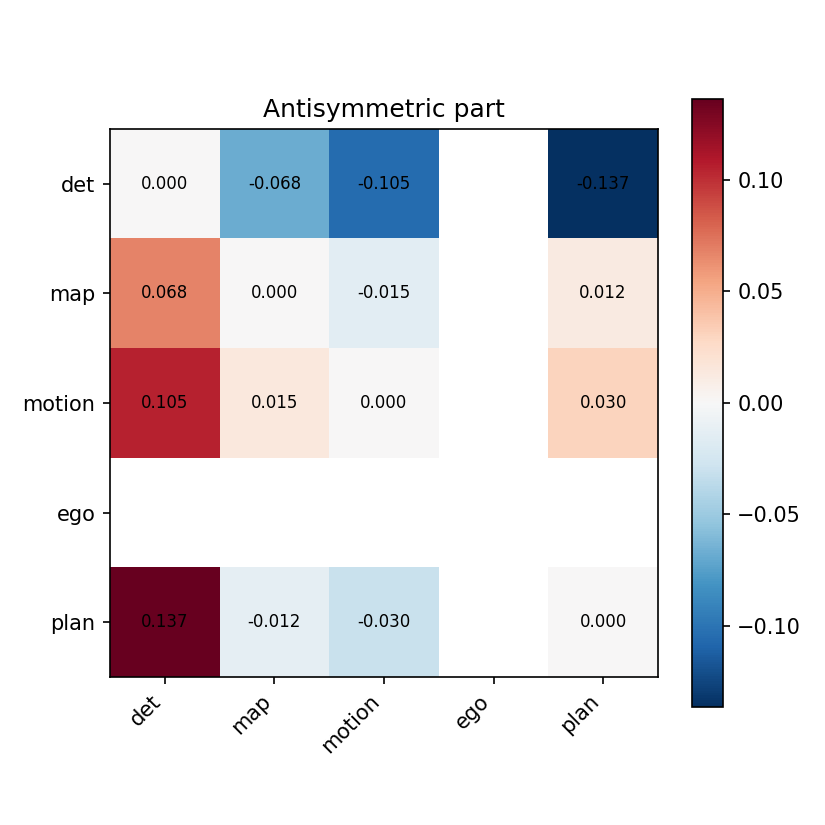

### 3ep — asymmetry/original.png

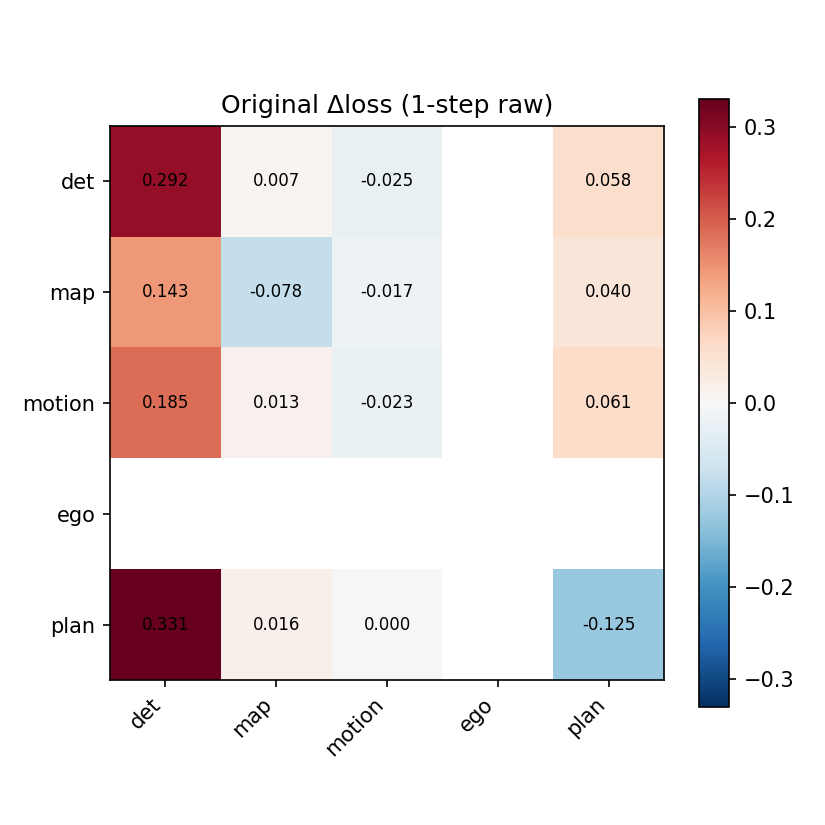

### 3ep — gradnorm/affinity_matrix_1step_raw.png

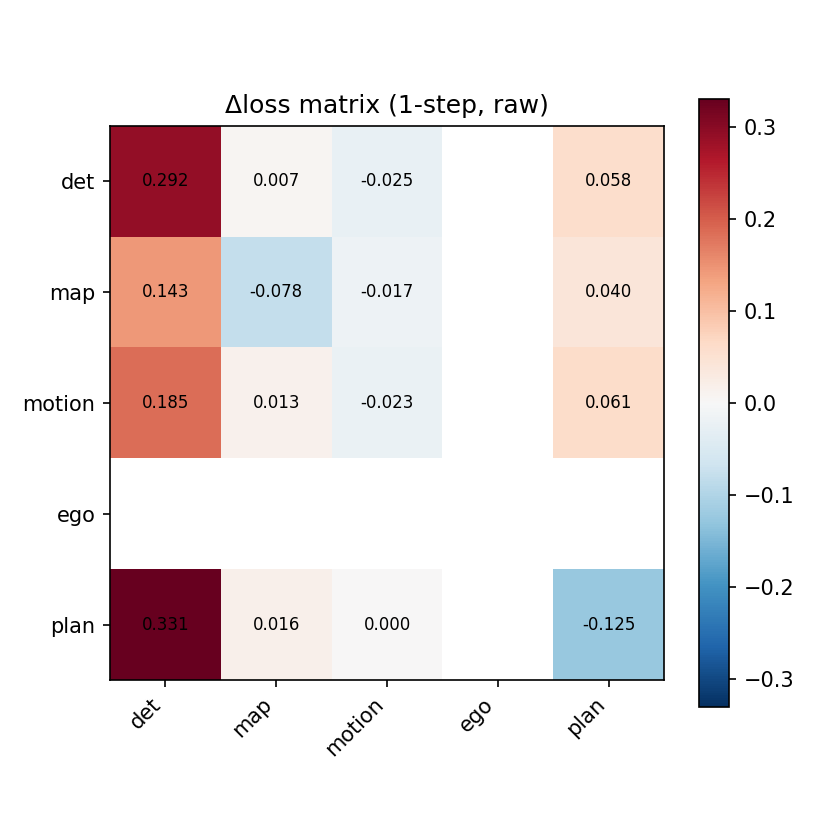

### 3ep — gradnorm/norm_ratio_heatmap.png

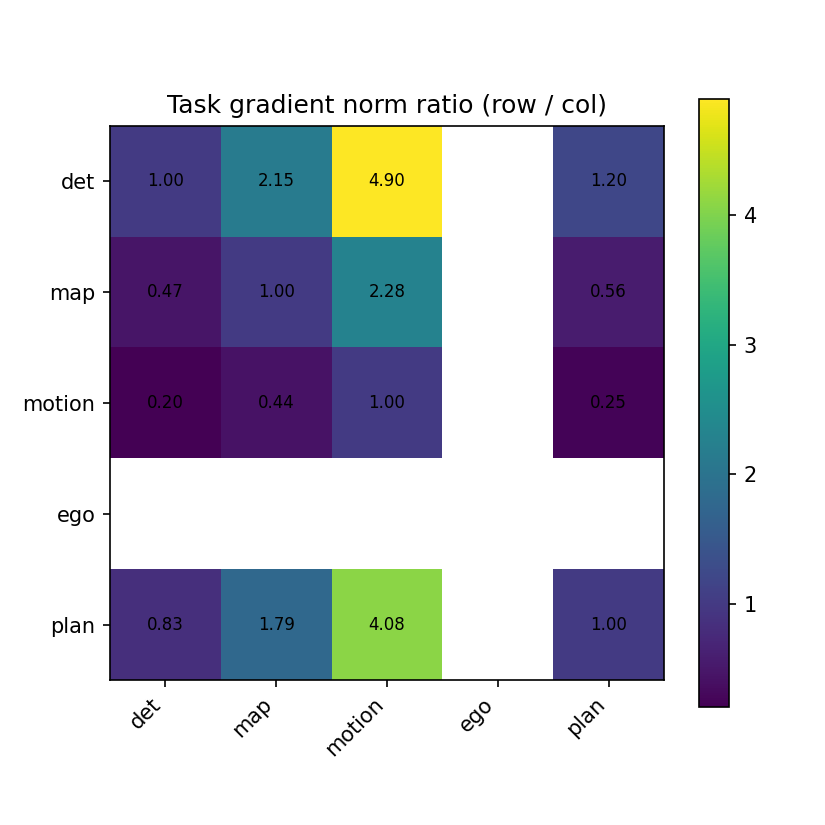

### 3ep — conflict/cosine_violin.png

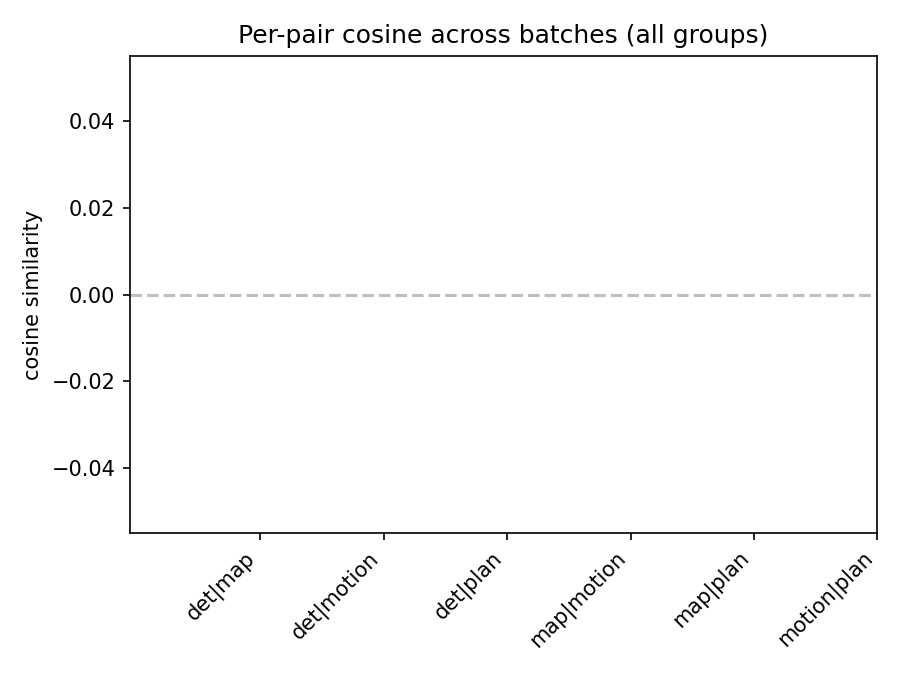

### 6ep — asymmetry/antisymmetric.png

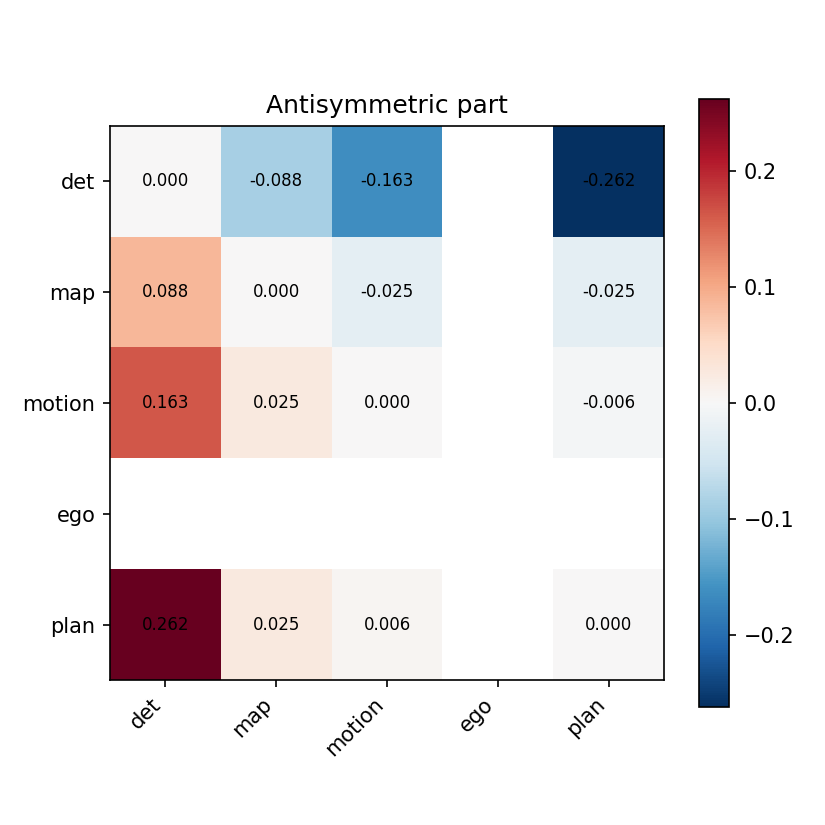

### 6ep — asymmetry/original.png

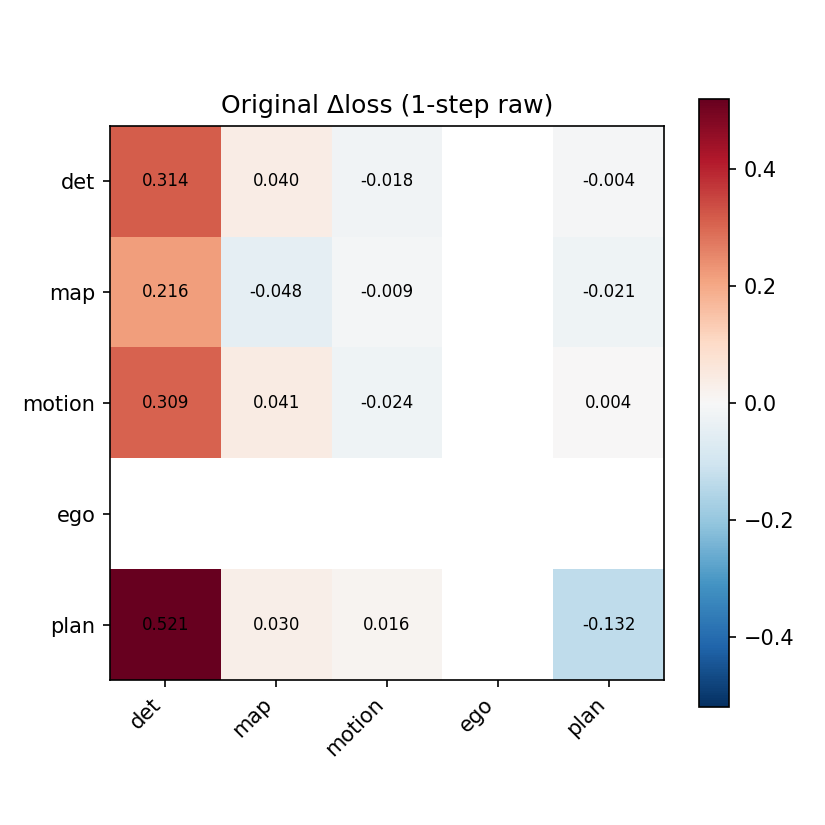

### 6ep — gradnorm/affinity_matrix_1step_raw.png

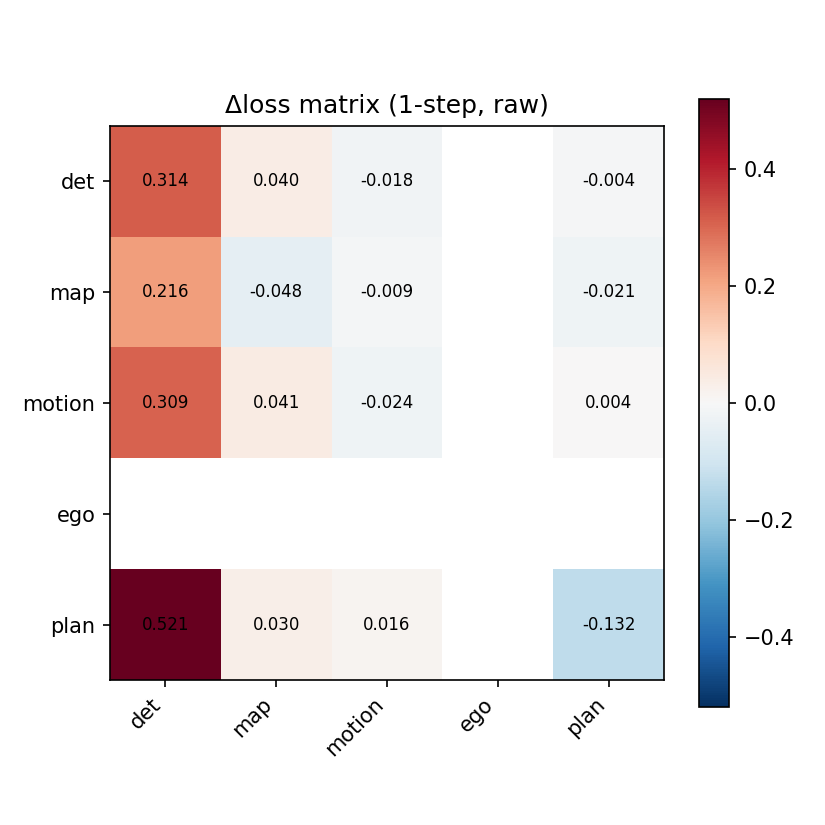

### 6ep — gradnorm/norm_ratio_heatmap.png

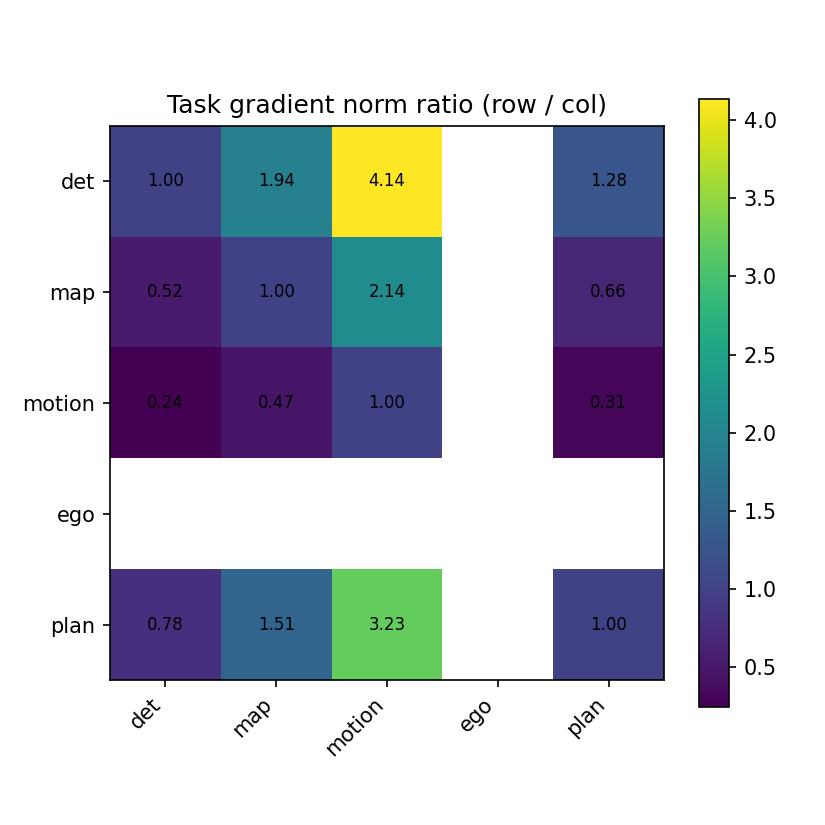

### 6ep — conflict/cosine_violin.png

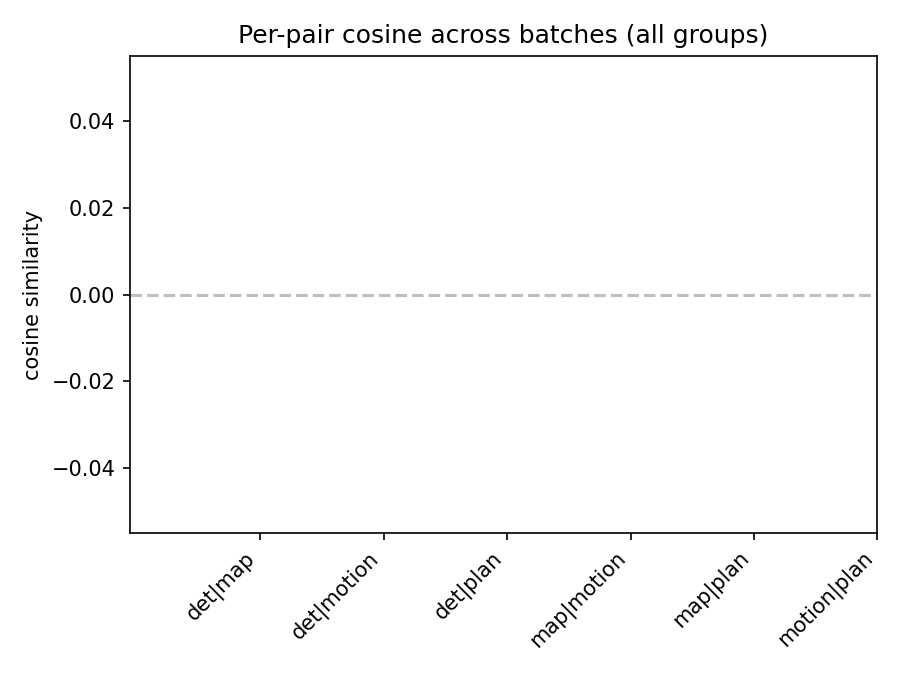

### 18ep — asymmetry/antisymmetric.png

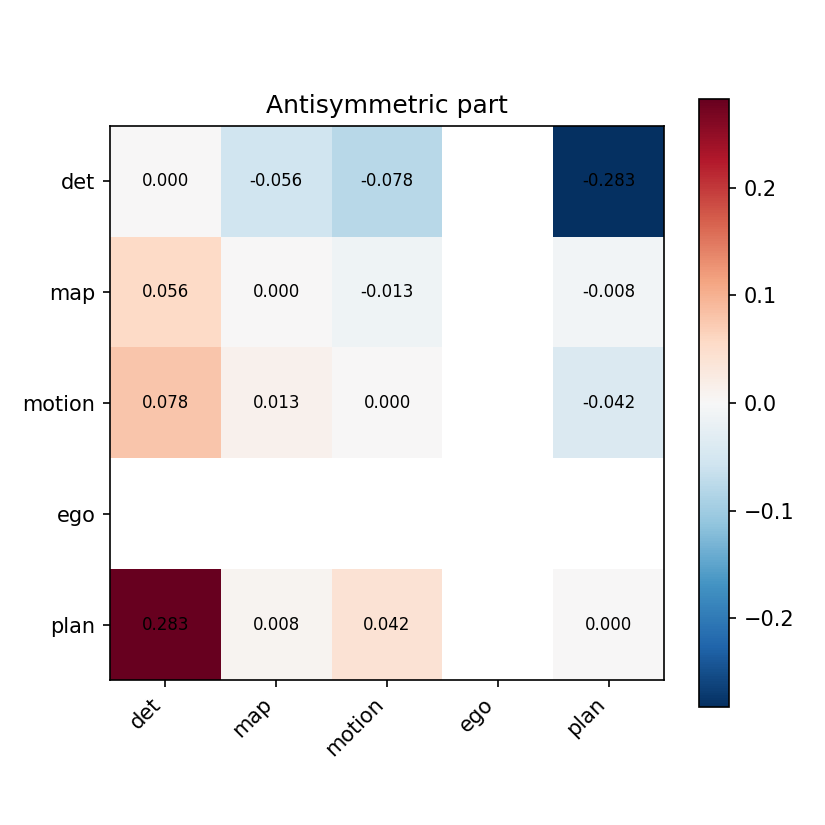

### 18ep — asymmetry/original.png

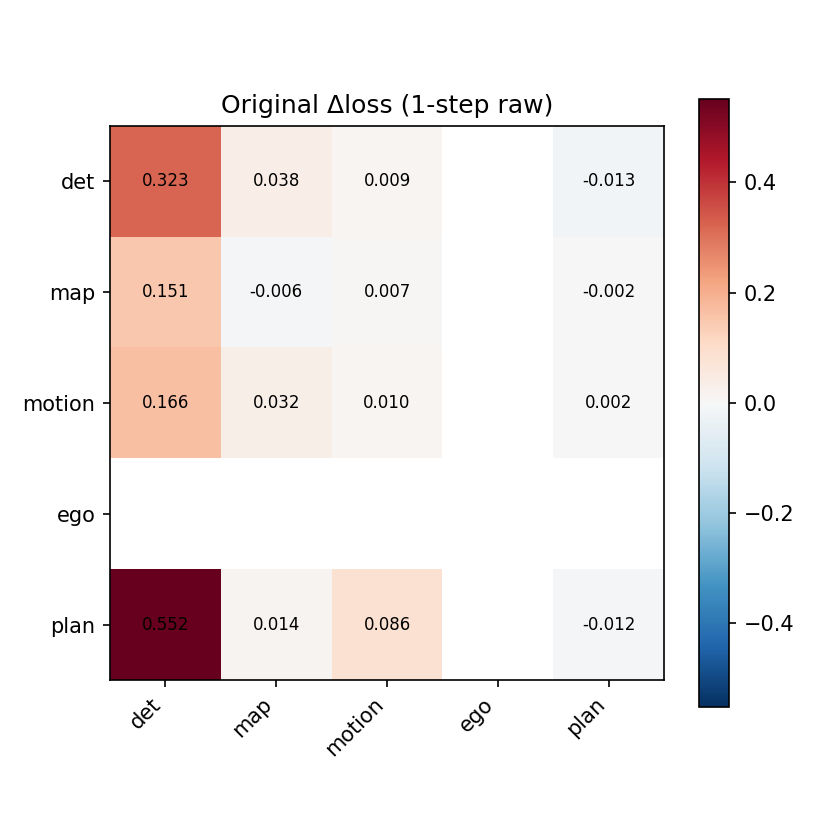

### 18ep — gradnorm/affinity_matrix_1step_raw.png

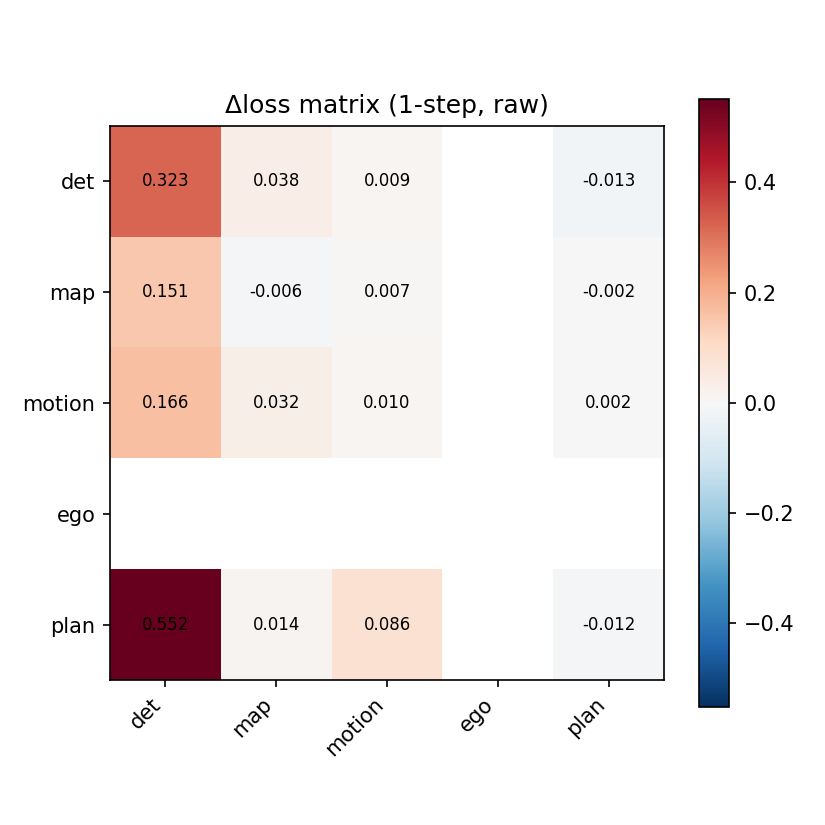

### 18ep — gradnorm/norm_ratio_heatmap.png

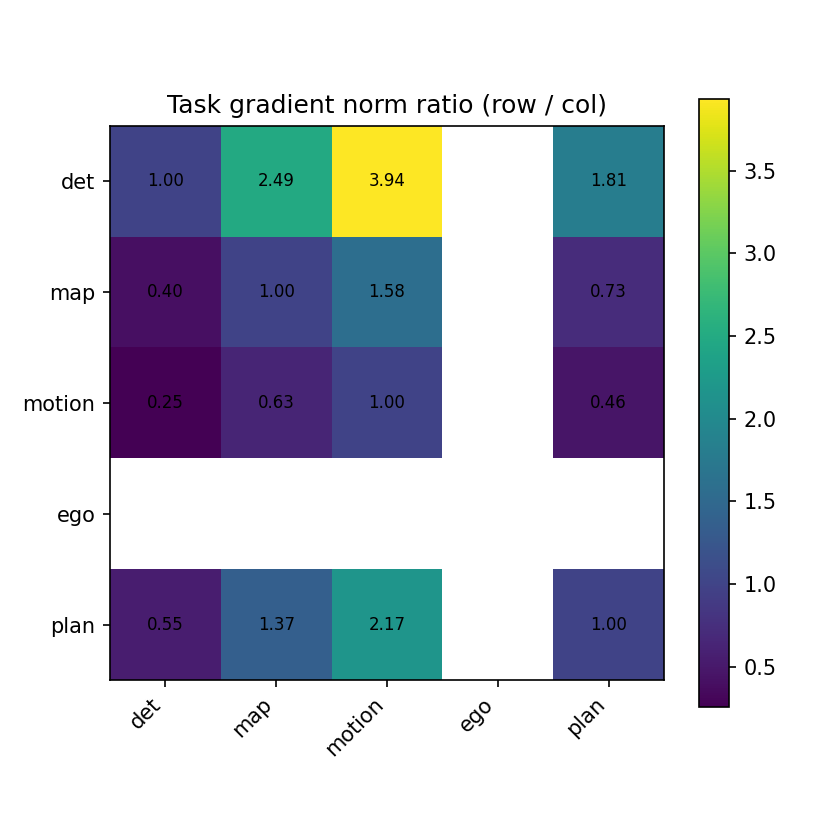

### 18ep — conflict/cosine_violin.png

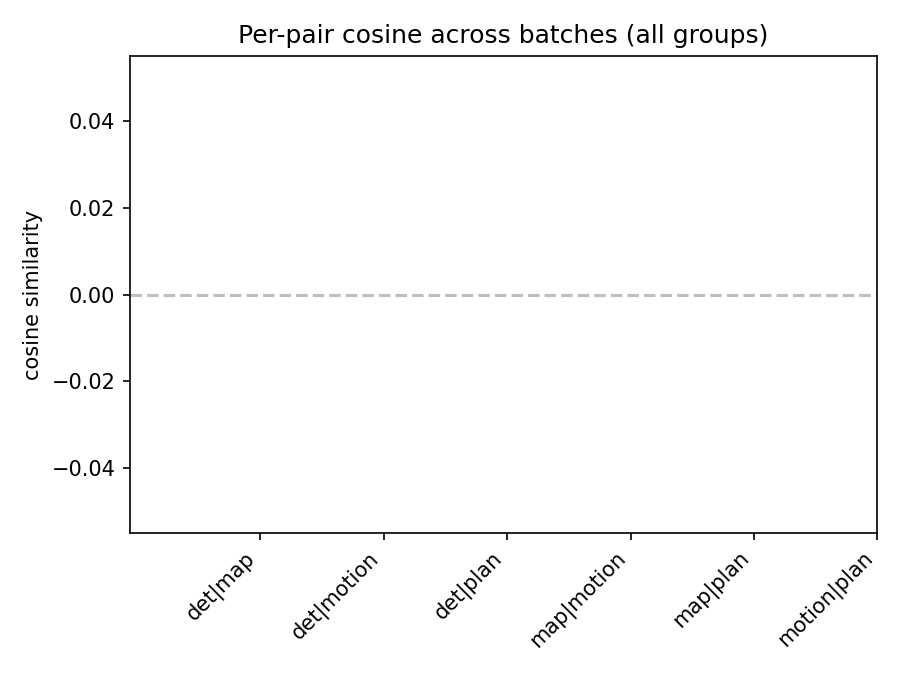

In [16]:
for ep in CKPTS:
    for sub, fname in [('asymmetry','antisymmetric.png'),
                       ('asymmetry','original.png'),
                       ('gradnorm','affinity_matrix_1step_raw.png'),
                       ('gradnorm','norm_ratio_heatmap.png'),
                       ('conflict','cosine_violin.png')]:
        p = BASE/f'ckpt_{ep}ep'/sub/fname
        if p.exists():
            display(Markdown(f'### {ep}ep — {sub}/{fname}'))
            display(Image(filename=str(p)))

---
## H. 보고용 요약 (한 페이지 분량)

노트북 마지막에 위에서 뽑은 숫자들 가지고 한 번 더 정리.

1. **Gradient magnitude imbalance가 학습 내내 유지되며 18ep 에서 더 심해진다.**
   18ep 평균 norm: det 1.62 / plan 0.89 / map 0.65 / motion 0.41.
   det/motion ratio ≈ 4×, backbone 최하단 layer에서는 ≈ 5×.
   → 공유 표상은 사실상 detection 에 의해 driven 됨.

2. **Probe matrix 는 plan ↔ det 가 가장 강한 비대칭 충돌임을 보여 준다.**
   18ep 1-step raw probe 에서 plan→det = +0.55 (det loss 증가, 가장 큰 양수 off-diagonal),
   det→plan = −0.013 (사실상 0). |antisym| 이 1ep 0.16 → 18ep 0.28 로 *증가*.
   plan task 학습은 det 에 해롭지만 그 역은 성립 안 함.

3. **det → motion / det → plan 는 cooperative 쪽**으로 18ep 에서 부호 바뀜
   (det step 이 motion / plan loss 를 낮추는 batch 가 절반 이상). det 자체가 너무 크기
   때문에 다른 task 의 cooperative residual 이 큰 step 에 묻혀 효과가 보이는 것일 수 있음.

4. **Cosine ↔ Δloss 상관계수는 약하다 (|r| 대부분 < 0.3, sign 도 epoch별로 뒤집힘).**
   → 단순 "cos < 0 이면 conflict" 휴리스틱은 이 모델에서 batch 단위 신호로 약함.
   PCGrad/CAGrad 류를 그대로 적용하기보다 **norm balancing** 쪽이 우선 검증해 볼 가치가 있음.

5. **Layer 분포**: det↔plan 충돌은 dec1_norm_0, dec0_ffn_identity_fc, dec3_pre_norm 등
   decoder 초~중반 norm/identity 경로에서 conflict_ratio 0.6+ 로 두드러짐.
   det↔motion 은 backbone 단계는 conflict 가 거의 없고 decoder 일부에서만 약하게 발생.

6. **Helpful-ratio collapse**: plan→motion = 0.50 → 0.42 → 0.41 → **0.11** 로 18ep 에 사실상
   plan step 은 motion 에 해로움. 같은 시기에 plan 의 norm 은 줄어들고 motion 의 norm 은
   증가 → plan 학습 신호가 약해지는 동안 motion 표상은 새로운 방향으로 빠르게 변하는 것으로
   해석 가능.

7. **Caveats / 데이터 한계**:
   - probe_matrix 의 ego row/column 은 NaN → script 의 task_prefix 매칭이 ego loss key 를
     못 찾는 것으로 보임 (`raw_vs_norm_symmetry` 의 Frobenius 도 전부 NaN 인 원인). 
     ego 까지 보려면 `match_loss_key` 의 prefix 매핑 보완 필요.
   - 모든 통계는 100 batch 샘플 (`n=100`) 기준. magnitude 비율과 helpful_ratio 의 
     epoch-trend 는 안정적이지만 1-step raw cosine 상관계수는 표본 변동이 클 수 있음.
   - normalized 분기 (per-task normalize 후 step) 결과가 별도로 존재하므로 "norm balancing 후
     interference" 비교에 바로 활용 가능.